# Employee Incentive & Retention Analytics
## Enterprise Incentive Servicing Analytics — Compensation Equity Model
**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees)  
**Goal:** Model compensation equity, incentive eligibility, simulated payouts, and attrition risk  
**Output:** `employee_incentive_final.csv` → imported directly into Power BI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries loaded.")

✅ All libraries loaded.


## 1. Load & Profile Data

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Shape: {df.shape}")
print(f"\nAttrition counts: {df['Attrition'].value_counts().to_dict()}")
print(f"Departments     : {list(df['Department'].unique())}")
print(f"Job Roles       : {list(df['JobRole'].unique())}")
print(f"Missing values  : {df.isnull().sum().sum()}")
df.head()

Shape: (1470, 35)

Attrition counts: {'No': 1233, 'Yes': 237}
Departments     : ['Sales', 'Research & Development', 'Human Resources']
Job Roles       : ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
Missing values  : 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


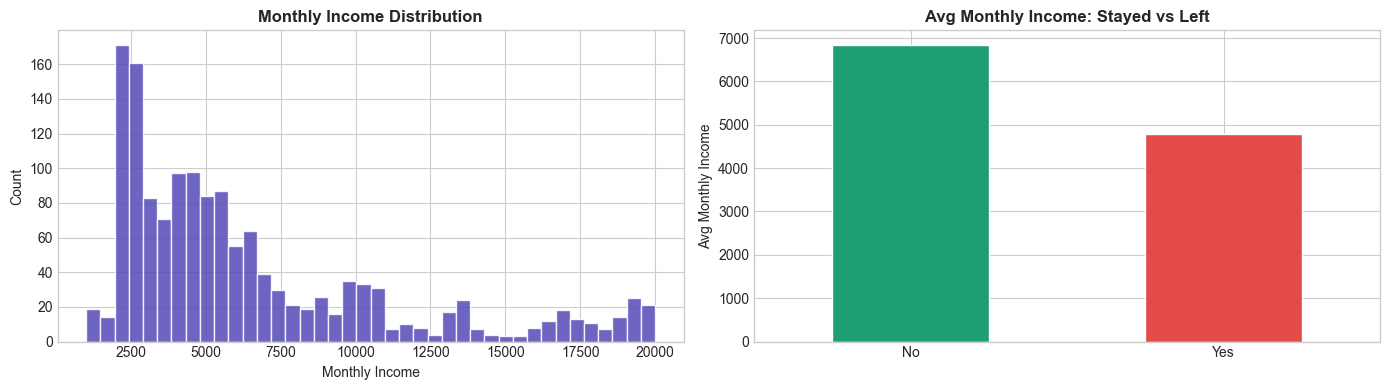

Avg income (Stayed): $6,833
Avg income (Left)  : $4,787


In [3]:
# Income distribution overview
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['MonthlyIncome'], bins=40, color='#534AB7', edgecolor='white', alpha=0.85)
axes[0].set_title('Monthly Income Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Count')

attrition_income = df.groupby('Attrition')['MonthlyIncome'].mean()
attrition_income.plot(kind='bar', ax=axes[1], color=['#1D9E75','#E24B4A'], edgecolor='white')
axes[1].set_title('Avg Monthly Income: Stayed vs Left', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Monthly Income')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(f"Avg income (Stayed): ${df[df['Attrition']=='No']['MonthlyIncome'].mean():,.0f}")
print(f"Avg income (Left)  : ${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():,.0f}")

## 2. Feature Engineering

In [4]:
df_model = df.copy()

# Binary targets
df_model['AttritionFlag'] = (df_model['Attrition'] == 'Yes').astype(int)
df_model['OverTime_enc']  = (df_model['OverTime'] == 'Yes').astype(int)

# Label encode categoricals for regression
le = LabelEncoder()
df_model['Department_enc'] = le.fit_transform(df_model['Department'])
df_model['JobRole_enc']    = le.fit_transform(df_model['JobRole'])
df_model['Gender_enc']     = le.fit_transform(df_model['Gender'])

print("✅ Feature encoding complete.")
print("\nEncoded mappings:")
for col in ['Department', 'JobRole']:
    mapping = dict(zip(df_model[col], df_model[f'{col}_enc']))
    print(f"  {col}: {dict(sorted(mapping.items(), key=lambda x: x[1]))}")

✅ Feature encoding complete.

Encoded mappings:
  Department: {'Human Resources': 0, 'Research & Development': 1, 'Sales': 2}
  JobRole: {'Healthcare Representative': 0, 'Human Resources': 1, 'Laboratory Technician': 2, 'Manager': 3, 'Manufacturing Director': 4, 'Research Director': 5, 'Research Scientist': 6, 'Sales Executive': 7, 'Sales Representative': 8}


## 3. Compensation Equity Model (Compa-Ratio)
**Method:** Linear regression predicts expected salary based on role, experience, education  
**Compa-Ratio** = Actual Salary / Expected Salary  
- `< 0.85` → Underpaid  
- `0.85 – 1.15` → Fair  
- `> 1.15` → Overpaid

In [5]:
features = [
    'PerformanceRating', 'TotalWorkingYears', 'Education',
    'Department_enc', 'JobRole_enc',
    'YearsAtCompany', 'YearsInCurrentRole'
]

X = df_model[features]
y = df_model['MonthlyIncome']

model = LinearRegression()
model.fit(X, y)

df_model['ExpectedSalary'] = model.predict(X)
df_model['CompRatio']      = df_model['MonthlyIncome'] / df_model['ExpectedSalary']

r2 = r2_score(y, df_model['ExpectedSalary'])
print(f"Regression R²: {r2:.4f}")
print(f"\nComp Ratio statistics:")
print(df_model['CompRatio'].describe().round(3))

# Segment
def comp_segment(ratio):
    if ratio < 0.85:   return 'Underpaid'
    elif ratio > 1.15: return 'Overpaid'
    else:              return 'Fair'

df_model['CompSegment'] = df_model['CompRatio'].apply(comp_segment)
print(f"\nSegment counts:\n{df_model['CompSegment'].value_counts()}")

Regression R²: 0.6053

Comp Ratio statistics:
count    1470.000
mean        1.020
std         0.427
min         0.201
25%         0.695
50%         0.982
75%         1.276
max         3.310
Name: CompRatio, dtype: float64

Segment counts:
CompSegment
Underpaid    578
Overpaid     515
Fair         377
Name: count, dtype: int64


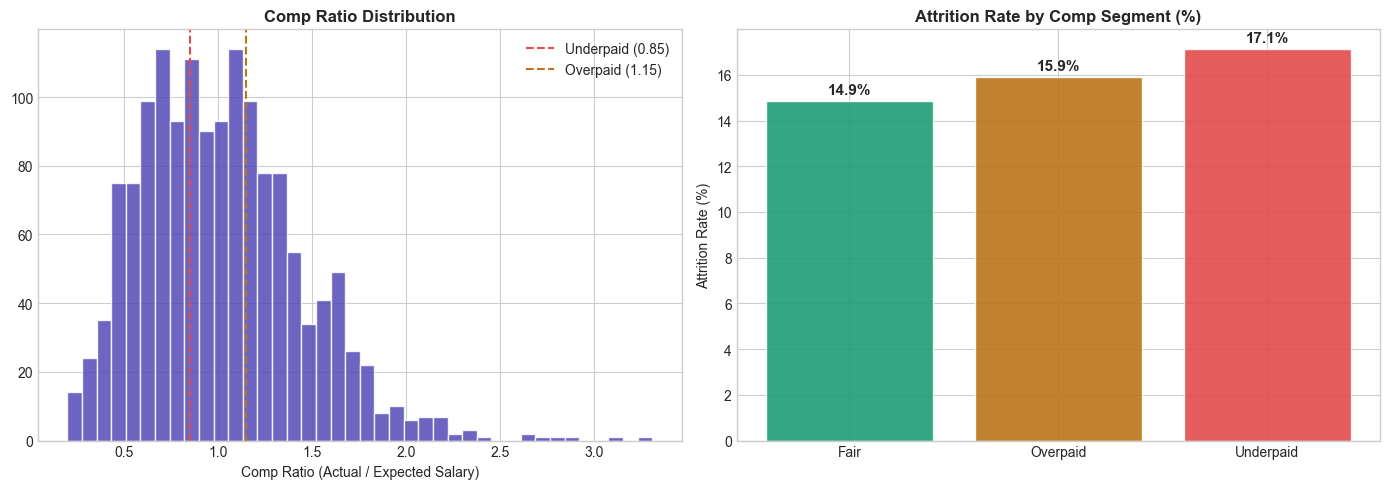

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comp Ratio histogram
axes[0].hist(df_model['CompRatio'], bins=40, color='#534AB7', edgecolor='white', alpha=0.85)
axes[0].axvline(0.85, color='#E24B4A', linestyle='--', linewidth=1.5, label='Underpaid (0.85)')
axes[0].axvline(1.15, color='#BA7517', linestyle='--', linewidth=1.5, label='Overpaid (1.15)')
axes[0].set_title('Comp Ratio Distribution', fontweight='bold')
axes[0].set_xlabel('Comp Ratio (Actual / Expected Salary)')
axes[0].legend()

# Attrition rate by comp segment
seg_attrition = df_model.groupby('CompSegment')['AttritionFlag'].mean() * 100
colors_map = {'Underpaid': '#E24B4A', 'Fair': '#1D9E75', 'Overpaid': '#BA7517'}
bars = axes[1].bar(seg_attrition.index,
                   seg_attrition.values,
                   color=[colors_map[x] for x in seg_attrition.index],
                   edgecolor='white', alpha=0.9)
axes[1].set_title('Attrition Rate by Comp Segment (%)', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
for bar, val in zip(bars, seg_attrition.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/comp_ratio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Incentive Eligibility Flag
**Incentive Eligibility Rule — eligible if ALL conditions met:**
1. PerformanceRating ≥ 3 (Excellent or above)
2. YearsAtCompany ≥ 2 (minimum tenure)
3. OverTime = No (not on overtime-only compensation)
4. CompRatio ≤ 1.15 (not already overpaid)

In [7]:
df_model['IncentiveEligible'] = (
    (df_model['PerformanceRating'] >= 3) &
    (df_model['YearsAtCompany'] >= 2) &
    (df_model['OverTime_enc'] == 0) &
    (df_model['CompRatio'] <= 1.15)
).astype(int)

total      = len(df_model)
eligible_n = df_model['IncentiveEligible'].sum()
pct        = eligible_n / total * 100

print("=== INCENTIVE ELIGIBILITY ===")
print(f"Total employees    : {total}")
print(f"Eligible           : {eligible_n} ({pct:.1f}%)")
print(f"Not eligible       : {total - eligible_n} ({100-pct:.1f}%)")

print("\nEligibility rate by department:")
print(df_model.groupby('Department')['IncentiveEligible'].mean().mul(100).round(1).astype(str) + '%')

=== INCENTIVE ELIGIBILITY ===
Total employees    : 1470
Eligible           : 607 (41.3%)
Not eligible       : 863 (58.7%)

Eligibility rate by department:
Department
Human Resources           33.3%
Research & Development    42.8%
Sales                     39.2%
Name: IncentiveEligible, dtype: object


## 5. Simulated Incentive Payout
**Formula:** `MonthlyIncome × 12 × (PercentSalaryHike / 100) × StockMultiplier`  
**Stock Multipliers:** Level 0 = 1.0x | Level 1 = 1.1x | Level 2 = 1.2x | Level 3 = 1.3x  
Payout = 0 for non-eligible employees (reconciliation gap detection)

In [8]:
stock_multiplier_map = {0: 1.0, 1: 1.1, 2: 1.2, 3: 1.3}
df_model['StockMultiplier'] = df_model['StockOptionLevel'].map(stock_multiplier_map)

df_model['SimulatedPayout'] = np.where(
    df_model['IncentiveEligible'] == 1,
    df_model['MonthlyIncome'] * 12 * (df_model['PercentSalaryHike'] / 100) * df_model['StockMultiplier'],
    0
)

eligible_df = df_model[df_model['IncentiveEligible'] == 1]

print("=== SIMULATED PAYOUT SUMMARY ===")
print(f"Total incentive pool      : ${eligible_df['SimulatedPayout'].sum():,.0f}")
print(f"Avg payout (eligible)     : ${eligible_df['SimulatedPayout'].mean():,.0f}")
print(f"Min payout                : ${eligible_df['SimulatedPayout'].min():,.0f}")
print(f"Max payout                : ${eligible_df['SimulatedPayout'].max():,.0f}")
print(f"\nPayout pool by department:")
print(eligible_df.groupby('Department')['SimulatedPayout'].sum().apply(lambda x: f'${x:,.0f}'))

=== SIMULATED PAYOUT SUMMARY ===
Total incentive pool      : $6,128,518
Avg payout (eligible)     : $10,096
Min payout                : $2,657
Max payout                : $57,506

Payout pool by department:
Department
Human Resources             $158,929
Research & Development    $3,826,346
Sales                     $2,143,243
Name: SimulatedPayout, dtype: object


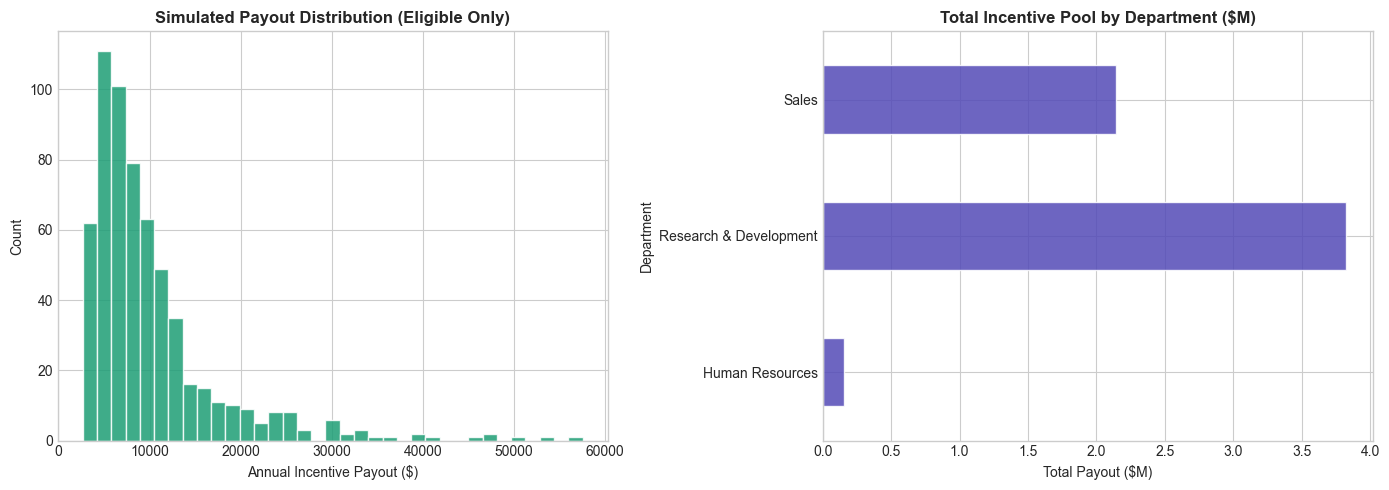

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payout distribution among eligible employees
axes[0].hist(eligible_df['SimulatedPayout'], bins=35,
             color='#1D9E75', edgecolor='white', alpha=0.85)
axes[0].set_title('Simulated Payout Distribution (Eligible Only)', fontweight='bold')
axes[0].set_xlabel('Annual Incentive Payout ($)')
axes[0].set_ylabel('Count')

# Payout pool by department
dept_pool = eligible_df.groupby('Department')['SimulatedPayout'].sum() / 1e6
dept_pool.plot(kind='barh', ax=axes[1], color='#534AB7', edgecolor='white', alpha=0.85)
axes[1].set_title('Total Incentive Pool by Department ($M)', fontweight='bold')
axes[1].set_xlabel('Total Payout ($M)')

plt.tight_layout()
plt.savefig('../data/processed/payout_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Attrition Risk Scoring
**Weighted business logic score:**
| Factor | Points |
|---|---|
| CompRatio < 0.85 (underpaid) | 30 |
| OverTime = Yes | 25 |
| YearsSinceLastPromotion > 3 | 20 |
| JobSatisfaction ≤ 2 | 15 |
| Eligible but SimulatedPayout = 0 (reconciliation gap) | 10 |

In [10]:
df_model['RiskScore'] = 0
df_model['RiskScore'] += (df_model['CompRatio'] < 0.85).astype(int) * 30
df_model['RiskScore'] += (df_model['OverTime_enc'] == 1).astype(int) * 25
df_model['RiskScore'] += (df_model['YearsSinceLastPromotion'] > 3).astype(int) * 20
df_model['RiskScore'] += (df_model['JobSatisfaction'] <= 2).astype(int) * 15
df_model['RiskScore'] += (
    (df_model['IncentiveEligible'] == 1) & (df_model['SimulatedPayout'] == 0)
).astype(int) * 10

def risk_tier(score):
    if score >= 50:   return 'High'
    elif score >= 25: return 'Medium'
    else:             return 'Stable'

df_model['AttritionRisk'] = df_model['RiskScore'].apply(risk_tier)

print("=== ATTRITION RISK TIERS ===")
print(df_model['AttritionRisk'].value_counts())

print("\nValidation — actual attrition rate by risk tier:")
validation = df_model.groupby('AttritionRisk')['AttritionFlag'].mean().mul(100).round(1)
for tier in ['High','Medium','Stable']:
    if tier in validation.index:
        print(f"  {tier:8s}: {validation[tier]}% actual attrition")

=== ATTRITION RISK TIERS ===
AttritionRisk
Medium    622
Stable    576
High      272
Name: count, dtype: int64

Validation — actual attrition rate by risk tier:
  High    : 24.3% actual attrition
  Medium  : 17.7% actual attrition
  Stable  : 10.6% actual attrition


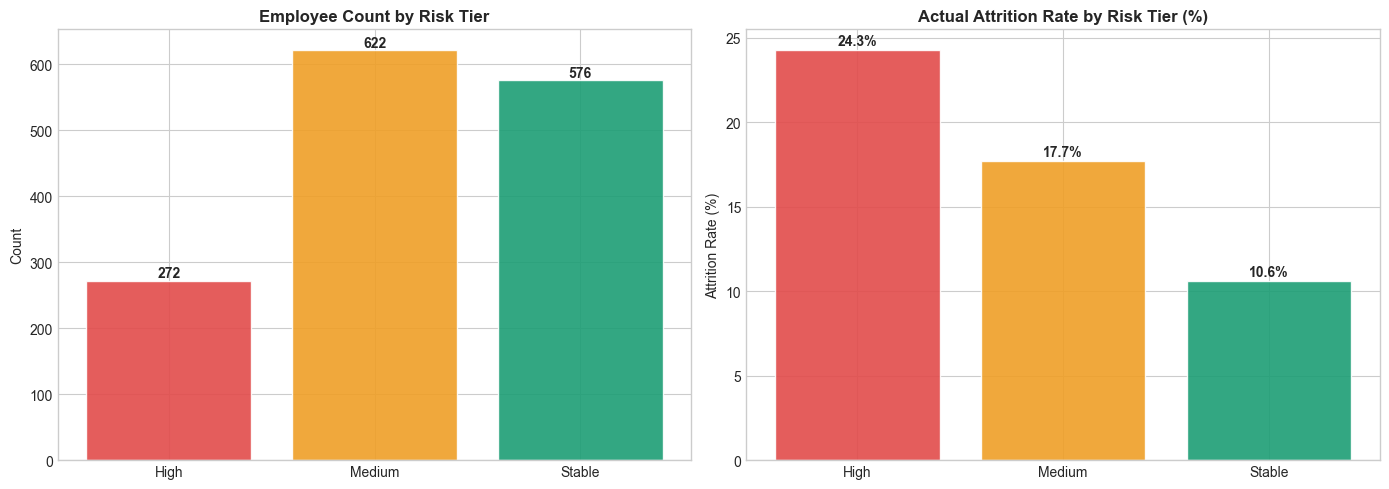

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk tier distribution
risk_counts = df_model['AttritionRisk'].value_counts().reindex(['High','Medium','Stable'])
colors_risk = ['#E24B4A','#EF9F27','#1D9E75']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors_risk, edgecolor='white', alpha=0.9)
axes[0].set_title('Employee Count by Risk Tier', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(risk_counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# Actual attrition rate by risk tier (validation)
risk_attrition = df_model.groupby('AttritionRisk')['AttritionFlag'].mean().mul(100).reindex(['High','Medium','Stable'])
axes[1].bar(risk_attrition.index, risk_attrition.values, color=colors_risk, edgecolor='white', alpha=0.9)
axes[1].set_title('Actual Attrition Rate by Risk Tier (%)', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
for i, (idx, val) in enumerate(risk_attrition.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/risk_tier_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Incentive ROI Framework

In [12]:
# Cost to replace = 50% annual salary (industry standard)
df_model['ReplacementCost'] = df_model['MonthlyIncome'] * 12 * 0.5

# Incentive gap = what it costs to bring underpaid eligible employees to expected salary
underpaid_eligible = df_model[
    (df_model['CompSegment'] == 'Underpaid') &
    (df_model['IncentiveEligible'] == 1)
].copy()
underpaid_eligible['IncentiveGapCost'] = (
    (underpaid_eligible['ExpectedSalary'] - underpaid_eligible['MonthlyIncome']) * 12
)

high_risk = df_model[df_model['AttritionRisk'] == 'High']

print("=== INCENTIVE ROI FRAMEWORK ===")
print(f"High-risk employees           : {len(high_risk)}")
print(f"Projected to leave (35%)      : {int(len(high_risk) * 0.35)}")
print(f"Replacement cost if no action : ${high_risk['ReplacementCost'].sum():,.0f}")
print(f"")
print(f"Underpaid + eligible employees: {len(underpaid_eligible)}")
print(f"Total incentive gap cost      : ${underpaid_eligible['IncentiveGapCost'].sum():,.0f}")
print(f"")
saving = high_risk['ReplacementCost'].sum() - underpaid_eligible['IncentiveGapCost'].sum()
print(f"Net saving from intervention  : ${saving:,.0f}")

print("\nIncentive gap urgency by department:")
dept_roi = underpaid_eligible.groupby('Department').agg(
    Employees=('EmployeeNumber','count'),
    TotalGapCost=('IncentiveGapCost','sum'),
    AvgCompRatio=('CompRatio','mean')
).round(2).sort_values('TotalGapCost', ascending=False)
print(dept_roi)

=== INCENTIVE ROI FRAMEWORK ===
High-risk employees           : 272
Projected to leave (35%)      : 95
Replacement cost if no action : $8,055,936

Underpaid + eligible employees: 371
Total incentive gap cost      : $11,759,351

Net saving from intervention  : $-3,703,415

Incentive gap urgency by department:
                        Employees  TotalGapCost  AvgCompRatio
Department                                                   
Research & Development        269    8642026.44          0.60
Sales                          85    2743237.30          0.67
Human Resources                17     374087.06          0.64


## 8. Export Final Dataset for Power BI

In [13]:
export_cols = [
    'EmployeeNumber', 'Age', 'Gender', 'Department', 'JobRole',
    'Education', 'EducationField', 'MaritalStatus',
    'MonthlyIncome', 'ExpectedSalary', 'CompRatio', 'CompSegment',
    'PercentSalaryHike', 'PerformanceRating', 'StockOptionLevel', 'StockMultiplier',
    'OverTime', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager', 'TotalWorkingYears', 'NumCompaniesWorked',
    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction',
    'TrainingTimesLastYear', 'BusinessTravel', 'DistanceFromHome',
    'IncentiveEligible', 'SimulatedPayout', 'RiskScore', 'AttritionRisk',
    'Attrition', 'AttritionFlag'
]

df_export = df_model[export_cols].copy()
df_export.to_csv('../data/processed/employee_incentive_final.csv', index=False)
print(f"✅ Exported {len(df_export)} rows × {len(df_export.columns)} columns")
print(f"   → data/processed/employee_incentive_final.csv")
print(f"\nNew columns added (Power BI key fields):")
new_cols = ['ExpectedSalary','CompRatio','CompSegment','StockMultiplier',
            'IncentiveEligible','SimulatedPayout','RiskScore','AttritionRisk','AttritionFlag']
for c in new_cols:
    dtype = df_export[c].dtype
    sample = df_export[c].iloc[0]
    print(f"  {c:<25} dtype={str(dtype):<10} sample={sample}")

✅ Exported 1470 rows × 36 columns
   → data/processed/employee_incentive_final.csv

New columns added (Power BI key fields):
  ExpectedSalary            dtype=float64    sample=5511.321816591122
  CompRatio                 dtype=float64    sample=1.0873979418075075
  CompSegment               dtype=object     sample=Fair
  StockMultiplier           dtype=float64    sample=1.0
  IncentiveEligible         dtype=int64      sample=0
  SimulatedPayout           dtype=float64    sample=0.0
  RiskScore                 dtype=int64      sample=25
  AttritionRisk             dtype=object     sample=Medium
  AttritionFlag             dtype=int64      sample=1


## 9. Summary — Key Numbers for README & Project Write-up

In [15]:
underpaid_elig_fresh = df_model[
    (df_model['CompSegment'] == 'Underpaid') & (df_model['IncentiveEligible'] == 1)
].copy()
underpaid_elig_fresh['IncentiveGapCost'] = (
    (underpaid_elig_fresh['ExpectedSalary'] - underpaid_elig_fresh['MonthlyIncome']) * 12
)

eligible_fresh = df_model[df_model['IncentiveEligible'] == 1]
pct_fresh      = df_model['IncentiveEligible'].mean() * 100

print("=" * 58)
print("  LAYER 1 COMPLETE — Numbers for README & Project Write-up")
print("=" * 58)
print(f"  Total employees analysed       : {len(df_model)}")
print(f"  Compensation model R²          : {r2:.4f}")
print(f"  Underpaid employees            : {(df_model['CompSegment']=='Underpaid').sum()}")
print(f"  Fair-comp employees            : {(df_model['CompSegment']=='Fair').sum()}")
print(f"  Overpaid employees             : {(df_model['CompSegment']=='Overpaid').sum()}")
print(f"  Incentive eligible             : {df_model['IncentiveEligible'].sum()} ({pct_fresh:.1f}%)")
print(f"  Total simulated payout pool    : ${eligible_fresh['SimulatedPayout'].sum():,.0f}")
print(f"  High-risk employees            : {(df_model['AttritionRisk']=='High').sum()}")
print(f"  Medium-risk employees          : {(df_model['AttritionRisk']=='Medium').sum()}")
print(f"  Incentive gap (underpaid)      : ${underpaid_elig_fresh['IncentiveGapCost'].sum():,.0f}")
print(f"  Replacement cost (high-risk)   : ${df_model[df_model['AttritionRisk']=='High']['ReplacementCost'].sum():,.0f}")


  LAYER 1 COMPLETE — Numbers for README & Project Write-up
  Total employees analysed       : 1470
  Compensation model R²          : 0.6053
  Underpaid employees            : 578
  Fair-comp employees            : 377
  Overpaid employees             : 515
  Incentive eligible             : 607 (41.3%)
  Total simulated payout pool    : $6,128,518
  High-risk employees            : 272
  Medium-risk employees          : 622
  Incentive gap (underpaid)      : $11,759,351
  Replacement cost (high-risk)   : $8,055,936
